# Подключение основные модулей

In [46]:
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt

# Подключение к локальному ClickHouse

In [47]:
client = clickhouse_connect.get_client(
    host='service.db_clickhouse',
    port=8123,
    username='default',
    password=''
)

# SQL запрос

In [48]:
sql = """SELECT * FROM "liquor"."liquor_sales" LIMIT 100;"""

In [149]:
sql = """WITH monthly_stats AS (
    SELECT
        toYYYYMM(Invoice_Date) AS Time,
        SUM(Sale_Dollars) AS Total,
        COUNT(Invoice_Item_Number) AS Invoices,
        AVG(Sale_Dollars) AS Monthly_Avg_Sale
    FROM "liquor"."liquor_sales"
    GROUP BY toYYYYMM(Invoice_Date)
)
SELECT
    Time,
    Total,
    Invoices,
    ROUND(Monthly_Avg_Sale, 2) AS AVG_Sale,
    ROUND(stddevPop(Monthly_Avg_Sale) OVER (ORDER BY Time), 2) AS STDDEV_POP,
    ROUND(stddevSamp(Monthly_Avg_Sale) OVER (ORDER BY Time), 2) AS STDDEV_SAMP,
    ROUND(quantile(0.1)(Total) OVER (ORDER BY Time), 2) AS PERCENTILE_10,
    ROUND(quantile(0.5)(Total) OVER (ORDER BY Time), 2) AS MEDIAN,
    ROUND(quantile(0.75)(Total) OVER (ORDER BY Time), 2) AS PERCENTILE_75,
    ROUND(quantile(0.9)(Total) OVER (ORDER BY Time), 2) AS PERCENTILE_90,
    MEDIAN - PERCENTILE_10 AS S1,
    MEDIAN + PERCENTILE_25 AS S2
FROM monthly_stats
ORDER BY Time;"""

In [50]:
# result = client.query_df(sql)
# result.head()

In [150]:
result = client.query(sql)
df = pd.DataFrame(result.result_rows, columns=result.column_names)
df['Time'] = pd.to_datetime(df['Time'], format='%Y%m')
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
df

,Time,Total,Invoices,AVG_Sale,STDDEV_POP,STDDEV_SAMP,PERCENTILE_10,MEDIAN,PERCENTILE_75,PERCENTILE_90,S1,S2
0,2012-01-01,15916194.22,147770,107.71,0.00,NaN,15916194.22,15916194.22,15916194.22,15916194.22,0.00,31832388.44
1,2012-02-01,18116104.07,156728,115.59,3.94,5.57,16136185.20,17016149.14,17566126.60,17896113.08,879963.94,33152334.34
2,2012-03-01,18139545.75,160535,112.99,3.28,4.02,16356176.19,18116104.07,18127824.91,18134857.41,1759927.88,34472280.26
3,2012-04-01,20004896.97,164970,121.26,4.88,5.64,16576167.17,18127824.91,18605883.55,19445291.60,1551657.74,34703992.08
4,2012-05-01,22193521.24,192270,115.43,4.38,4.90,16796158.16,18139545.75,20004896.97,21318071.53,1343387.59,34935703.91
...,...,...,...,...,...,...,...,...,...,...,...,...
100,2020-05-01,32081114.18,233910,137.15,13.00,13.06,19126692.82,24429677.97,28078111.23,31385430.79,5302985.15,43556370.79
101,2020-06-01,36007843.00,242268,148.63,13.03,13.09,19132351.76,24446692.76,28190142.21,31927081.29,5314341.00,43579044.52
102,2020-07-01,34272654.20,225113,152.25,13.09,13.16,19138010.70,24463707.55,28325874.58,32062344.28,5325696.85,43601718.25
103,2020-08-01,33722408.12,212382,158.78,13.26,13.33,19143669.65,24467583.26,28461704.28,32126402.26,5323913.61,43611252.91


In [151]:
df.describe(include=['number'])

,Total,Invoices,AVG_Sale,STDDEV_POP,STDDEV_SAMP
count,1.050000e+02,105.000000,105.000000,105.000000,104.000000
mean,2.525920e+07,187302.504762,134.006095,11.814381,12.137212
std,4.912343e+06,22535.541832,13.644654,2.487476,2.130704
min,1.591619e+07,147770.000000,107.710000,0.000000,4.020000
25%,2.194735e+07,169732.000000,123.730000,11.550000,11.627500
50%,2.447146e+07,187376.000000,132.290000,12.180000,12.355000
75%,2.857403e+07,203522.000000,143.720000,13.030000,13.122500
max,3.678084e+07,242268.000000,169.590000,15.780000,16.630000


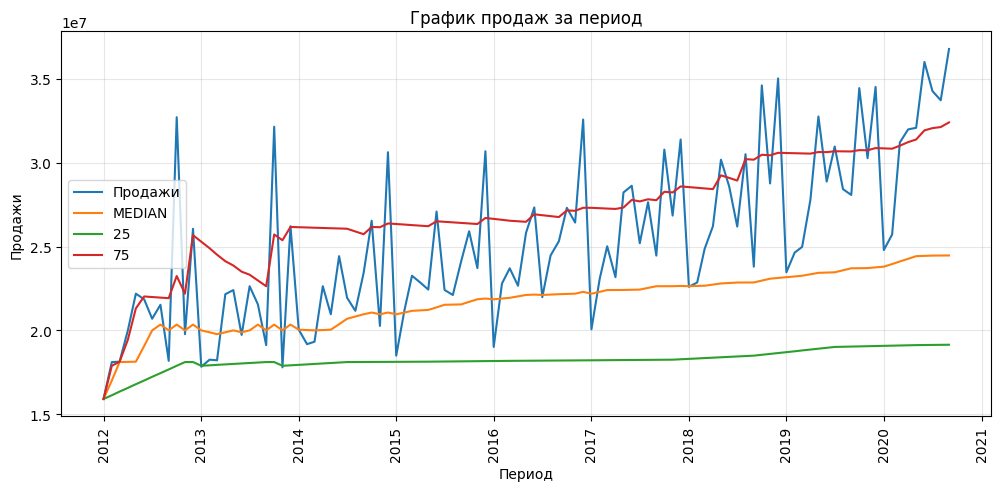

In [152]:
plt.figure(figsize=(12, 5))
plt.plot(df["Time"], df["Total"], label="Продажи")
plt.plot(df["Time"], df["MEDIAN"], label="MEDIAN")
plt.plot(df["Time"], df["PERCENTILE_10"], label="25")
plt.plot(df["Time"], df["PERCENTILE_90"], label="75")

plt.xticks(rotation="vertical")
plt.grid(True, alpha=0.3)
plt.xlabel("Период")
plt.ylabel("Продажи")
plt.title("График продаж за период")
plt.legend()

plt.show()


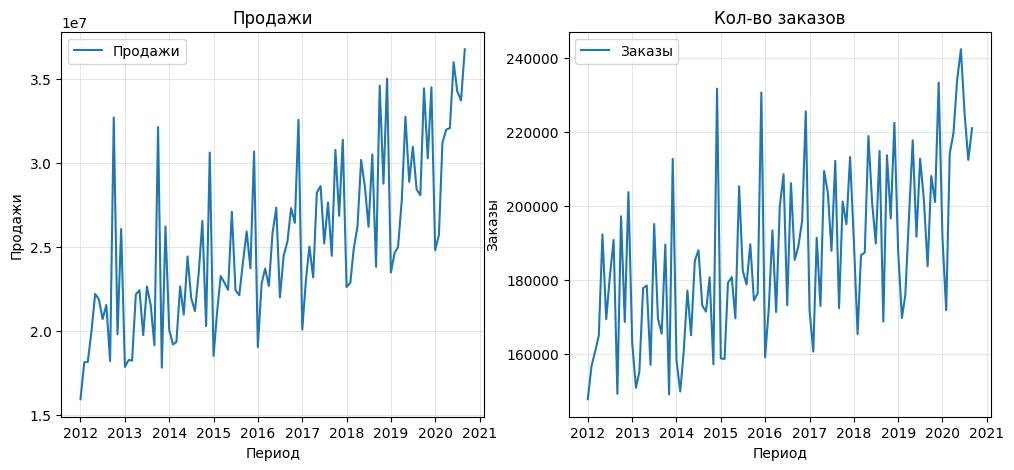

In [108]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(df["Time"], df["Total"], label="Продажи")
ax1.set_ylabel("Продажи")
ax1.set_xlabel("Период")
ax1.set_title("Продажи")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df["Time"], df["Invoices"], label="Заказы")
ax2.set_ylabel("Заказы")
ax2.set_xlabel("Период")
ax2.set_title("Кол-во заказов")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()